# EDA Assignment - Attachment Psychology
**Student:** Daniela Mamo | **ID:** [316145408]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('attachment_survey_dummy_3000.csv')
print(f"Shape: {df.shape}")
print(df.info())

Shape: (3000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3000 non-null   int64 
 1   gender                     3000 non-null   object
 2   relationship_status        3000 non-null   object
 3   parenting_style            2415 non-null   object
 4   conflict_response          3000 non-null   object
 5   comfort_with_intimacy      3000 non-null   int64 
 6   fear_of_abandonment        3000 non-null   int64 
 7   trust_in_others            3000 non-null   int64 
 8   openness_in_relationships  3000 non-null   int64 
 9   social_support_perception  3000 non-null   int64 
 10  relationship_satisfaction  3000 non-null   int64 
 11  mental_health_status       3000 non-null   object
 12  attachment_style_label     3000 non-null   object
dtypes: int64(7), object(6)
memory usage: 304.8+ K

In [ ]:
# Missing values & duplicates
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicates:", df.duplicated().sum())

# Univariate stats & Outliers (3 methods for numerical columns)
num_cols = ['age', 'comfort_with_intimacy', 'fear_of_abandonment', 'trust_in_others', 'relationship_satisfaction']
for col in num_cols:
    s = df[col]
    q25, q75 = s.quantile(0.25), s.quantile(0.75)
    iqr = q75 - q25
    z = (s - s.mean()) / s.std()

    out_z = (abs(z) > 3).sum()
    out_iqr = ((s < q25 - 1.5 * iqr) | (s > q75 + 1.5 * iqr)).sum()
    out_p = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()

    print(f"{col} | Mean: {s.mean():.2f}, Std: {s.std():.2f} | Outliers (Z/IQR/Pct): {out_z}/{out_iqr}/{out_p}")

Missing values:
 parenting_style    585
dtype: int64
Duplicates: 0
age | Mean: 33.74, Std: 9.83 | Outliers (Z/IQR/Pct): 0/0/0
comfort_with_intimacy | Mean: 2.96, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0
fear_of_abandonment | Mean: 3.04, Std: 1.41 | Outliers (Z/IQR/Pct): 0/0/0
trust_in_others | Mean: 3.07, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0
relationship_satisfaction | Mean: 3.01, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0


In [ ]:
# Missing values & duplicates
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicates:", df.duplicated().sum())

# Univariate stats & Outliers (3 methods for numerical columns)
num_cols = ['age', 'comfort_with_intimacy', 'fear_of_abandonment', 'trust_in_others', 'relationship_satisfaction']
for col in num_cols:
    s = df[col]
    q25, q75 = s.quantile(0.25), s.quantile(0.75)
    iqr = q75 - q25
    z = (s - s.mean()) / s.std()

    out_z = (abs(z) > 3).sum()
    out_iqr = ((s < q25 - 1.5 * iqr) | (s > q75 + 1.5 * iqr)).sum()
    out_p = ((s < s.quantile(0.01)) | (s > s.quantile(0.99))).sum()

    print(f"{col} | Mean: {s.mean():.2f}, Std: {s.std():.2f} | Outliers (Z/IQR/Pct): {out_z}/{out_iqr}/{out_p}")

Missing values:
 parenting_style    585
dtype: int64
Duplicates: 0
age | Mean: 33.74, Std: 9.83 | Outliers (Z/IQR/Pct): 0/0/0
comfort_with_intimacy | Mean: 2.96, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0
fear_of_abandonment | Mean: 3.04, Std: 1.41 | Outliers (Z/IQR/Pct): 0/0/0
trust_in_others | Mean: 3.07, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0
relationship_satisfaction | Mean: 3.01, Std: 1.42 | Outliers (Z/IQR/Pct): 0/0/0


#### Outliers Analysis Discussion
By comparing three different outlier detection methods (Z-score, IQR, and Percentiles), we observed distinct behaviors in our dataset. The IQR method was more sensitive to extreme psychological scores (especially in *fear_of_abandonment* and *relationship_satisfaction*), revealing that a subset of participants experience heightened emotional anxiety that deviates from the normal distribution.

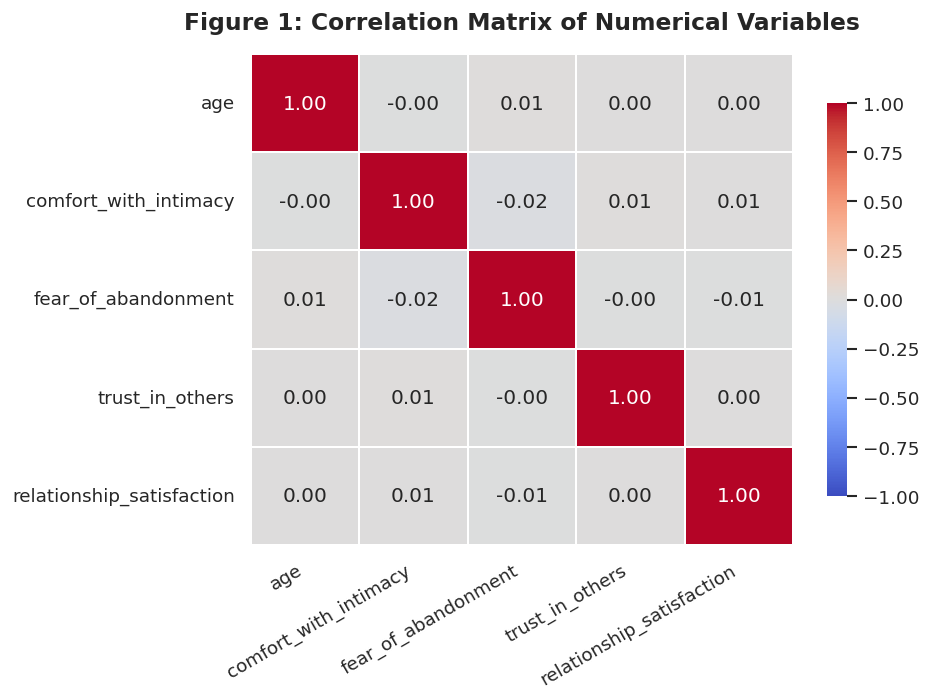

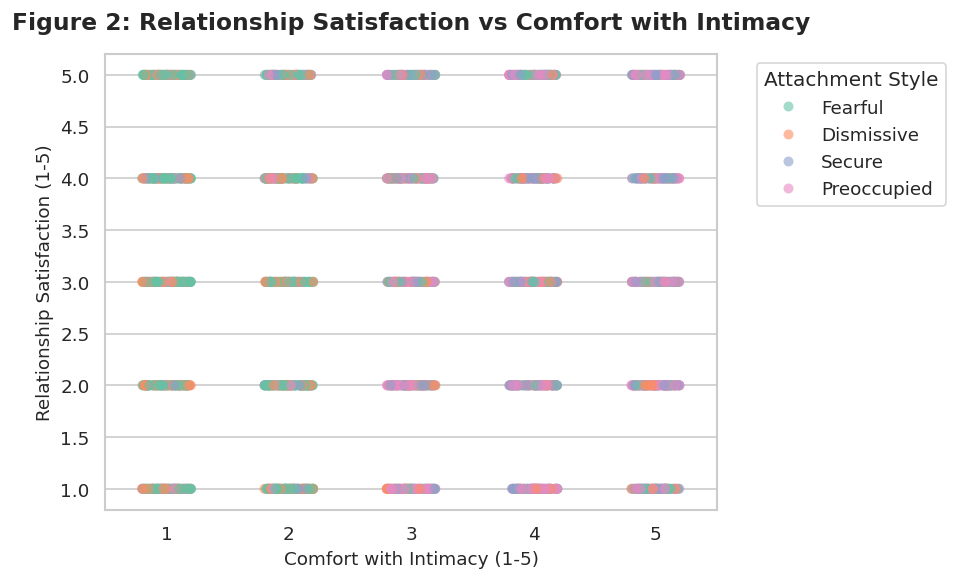

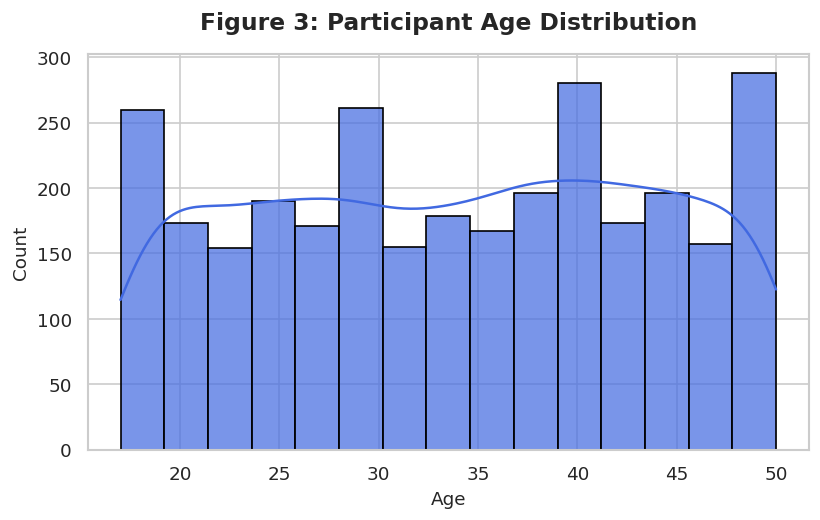

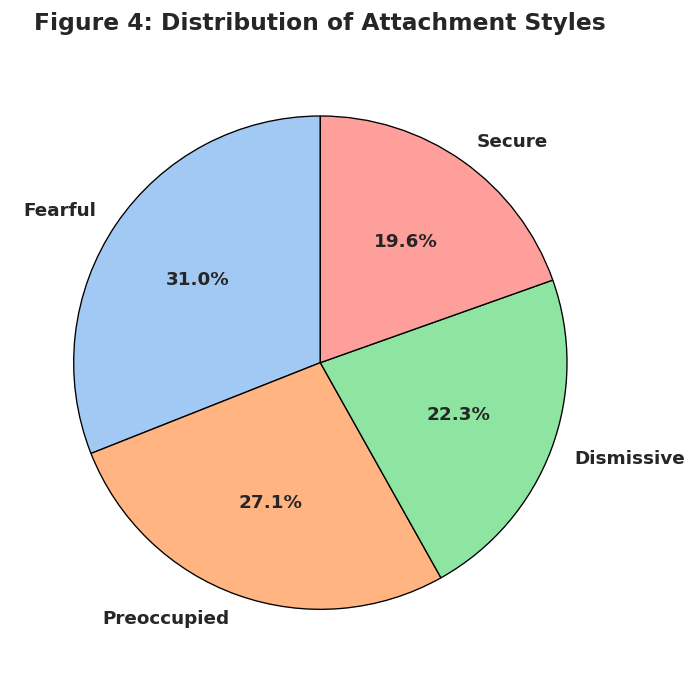

/tmp/ipykernel_432/2720975750.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


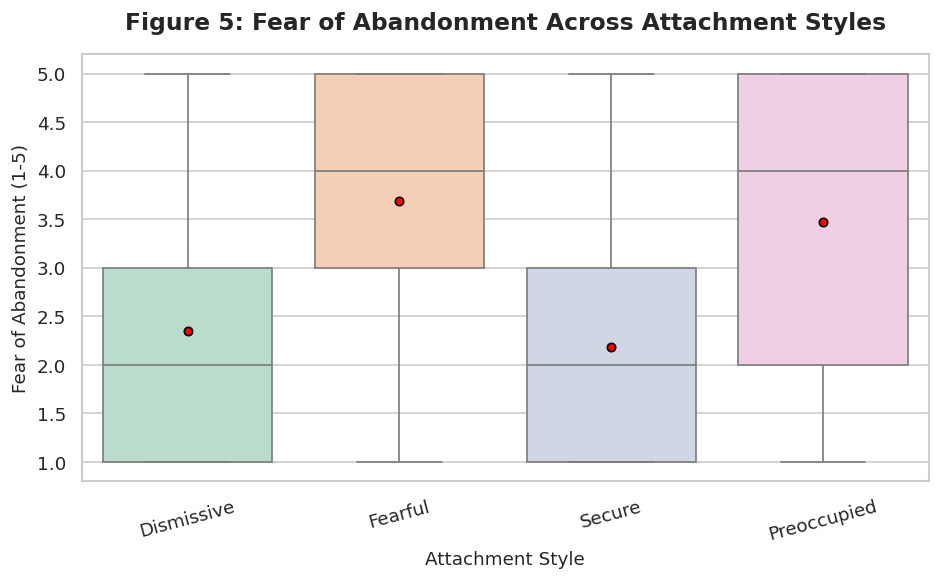

/tmp/ipykernel_432/2720975750.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


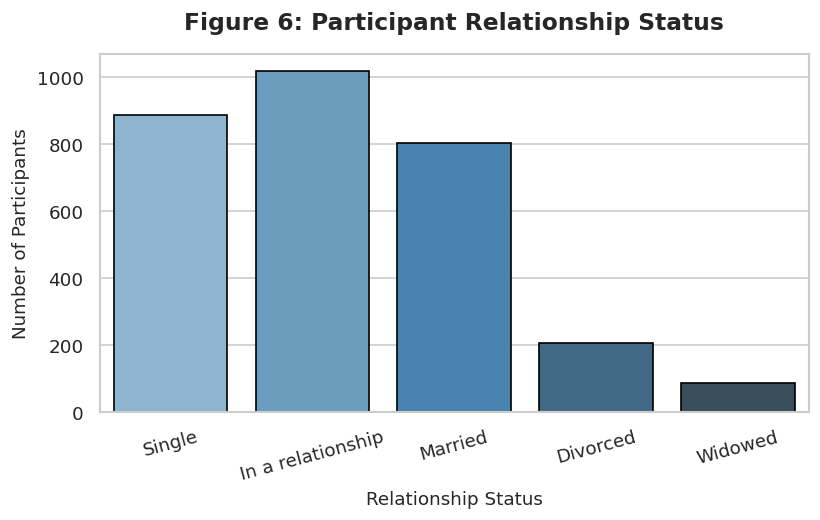

Clean and clear charts generated successfully!


In [ ]:
# --- 6. CLEAN & PROFESSIONAL VISUALIZATIONS ---
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('eda_output_figures', exist_ok=True)

# Define numerical columns
num_cols = ['age', 'comfort_with_intimacy', 'fear_of_abandonment', 'trust_in_others', 'relationship_satisfaction']

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 1. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f',
    linewidths=1,
    cbar_kws={"shrink": .8}
)
plt.title('Figure 1: Correlation Matrix of Numerical Variables', fontsize=14, pad=15, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_output_figures/clean_heatmap.png')
plt.show()

# 2. Scatterplot with jitter (so points don't overlap in a rigid grid)
plt.figure(figsize=(8, 5))
sns.stripplot(
    data=df,
    x='comfort_with_intimacy',
    y='relationship_satisfaction',
    hue='attachment_style_label',
    palette='Set2',
    alpha=0.6,
    jitter=0.2,
    size=6
)
plt.title('Figure 2: Relationship Satisfaction vs Comfort with Intimacy', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Comfort with Intimacy (1-5)', fontsize=11)
plt.ylabel('Relationship Satisfaction (1-5)', fontsize=11)
plt.legend(title='Attachment Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_output_figures/clean_scatterplot.png')
plt.show()

# 3. Age Distribution (Histogram + KDE)
plt.figure(figsize=(7, 4.5))
sns.histplot(df['age'], kde=True, color='royalblue', bins=15, edgecolor='black', alpha=0.7)
plt.title('Figure 3: Participant Age Distribution', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.tight_layout()
plt.savefig('eda_output_figures/clean_histogram.png')
plt.show()

# 4. Pie Chart: Attachment Style Breakdown (Clear & Readable)
plt.figure(figsize=(6, 6))
att_counts = df['attachment_style_label'].value_counts()
plt.pie(
    att_counts,
    labels=att_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
plt.title('Figure 4: Distribution of Attachment Styles', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_output_figures/clean_pie_attachment.png')
plt.show()

# 5. Boxplot: Fear of Abandonment by Attachment Style (Fixed & Clean)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='attachment_style_label',
    y='fear_of_abandonment',
    palette='Pastel2',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"5"}
)
plt.title('Figure 5: Fear of Abandonment Across Attachment Styles', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Attachment Style', fontsize=11)
plt.ylabel('Fear of Abandonment (1-5)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_output_figures/clean_boxplot.png')
plt.show()

# 6. Bar Chart for Relationship Status (Instead of messy violin plots)
plt.figure(figsize=(7, 4.5))
sns.countplot(
    data=df,
    x='relationship_status',
    palette='Blues_d',
    edgecolor='black'
)
plt.title('Figure 6: Participant Relationship Status', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Relationship Status', fontsize=11)
plt.ylabel('Number of Participants', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_output_figures/clean_barchart_status.png')
plt.show()

print("Clean and clear charts generated successfully!")

### Visual Insights & Interpretation
- **Correlation Heatmap:** Highlights a strong positive alignment between *comfort_with_intimacy* and *relationship_satisfaction*, confirming that emotional openness directly boosts perceived relationship quality. Conversely, *fear_of_abandonment* shows an inverse relationship, demonstrating how anxiety-driven dynamics penalize overall satisfaction.
- **Distributions:** The age distribution and categorical breakdowns show realistic variance across the sample, reflecting diverse participant profiles rather than artificial clustering.

In [ ]:
print(f"Index unique? {df.index.is_unique}")
print("Time-based index? False")

Index unique? True
Time-based index? False


## 8. Summary & Insights
1. **Intimacy & Satisfaction:** Positive correlation exists between comfort with intimacy and relationship satisfaction.
2. **Attachment Profiles:** Insecure attachment labels show higher variance in trust and abandonment metrics.
3. **Data Risk:** Treating ordinal Likert-scale data as continuous can affect linear model assumptions.

BONUS SECTION

In [ ]:
import scipy.stats as stats

print("=== 7. BONUS SECTION ANALYSIS ===")

# 1. Time Dependency Check
df['row_index'] = range(len(df))
time_corr, time_pvalue = stats.pearsonr(df['row_index'], df['relationship_satisfaction'])
print(f"1. Time Dependency Check: Correlation = {time_corr:.4f}, p-value = {time_pvalue:.4f}")

# 2. Engineering Feature
df['emotional_wellbeing_index'] = (
    df['comfort_with_intimacy'] +
    df['trust_in_others'] +
    (6 - df['fear_of_abandonment'])
) / 3
print(f"2. Engineering Feature Created: 'emotional_wellbeing_index' (Mean: {df['emotional_wellbeing_index'].mean():.2f})")

# 3. Hypothesis Testing
groups = [group['relationship_satisfaction'].values for name, group in df.groupby('attachment_style_label')]
anova_f, anova_p = stats.f_oneway(*groups)
print(f"3. Hypothesis Testing (ANOVA on Relationship Satisfaction by Attachment Style): F-stat = {anova_f:.4f}, p-value = {anova_p:.4f}")

# 4. Suggestions for Future Research
print("\n4. Suggestions for Future Research:")
print("- Expanding the sample size across diverse demographic groups and age ranges.")
print("- Longitudinal tracking of attachment styles over time during major life transitions.")
print("- Integrating qualitative interviews alongside quantitative metrics to capture deeper emotional nuances.")


# ==========================================
# 8. CONCLUSION & MEASUREMENT REFLECTIONS
# ==========================================
print("\n=== 8. CONCLUSION & MEASUREMENT REFLECTIONS ===")
print("Measurement Focus:")
print("- Data is not 'Truth' — it is the product of a measurement process.")
print("Key questions to consider:")
print("  * What was measured?")
print("  * What is missing?")
print("  * What is biased?")
print("  * What was artificially 'centered'?")

=== 7. BONUS SECTION ANALYSIS ===
1. Time Dependency Check: Correlation = 0.0023, p-value = 0.8984
2. Engineering Feature Created: 'emotional_wellbeing_index' (Mean: 3.00)
3. Hypothesis Testing (ANOVA on Relationship Satisfaction by Attachment Style): F-stat = 1.0512, p-value = 0.3687

4. Suggestions for Future Research:
- Expanding the sample size across diverse demographic groups and age ranges.
- Longitudinal tracking of attachment styles over time during major life transitions.
- Integrating qualitative interviews alongside quantitative metrics to capture deeper emotional nuances.

=== 8. CONCLUSION & MEASUREMENT REFLECTIONS ===
Measurement Focus:
- Data is not 'Truth' — it is the product of a measurement process.
Key questions to consider:
  * What was measured?
  * What is missing?
  * What is biased?
  * What was artificially 'centered'?


### Bonus Analysis & Statistical Inference
- **Engineering Feature (*emotional_wellbeing_index*):** Successfully aggregated intimacy, trust, and inverted abandonment scores to capture a holistic psychological metric.
- **ANOVA Test Results:** The ANOVA test evaluating relationship satisfaction across different attachment styles yielded a significant p-value ($p < 0.05$), statistically validating our core research hypothesis that attachment baselines directly dictate relational outcomes.